In [11]:
from haversine import haversine_vector, Unit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris, load_wine
import warnings
import platform

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


# 1번 (1-1)

### 평균 배송일이 늦었음에도 불구하고 평균 리뷰가 좋은 주들이 존재함.

가설1: 이유는 카테고리 때문일 것이다.

가설2: 이유는 배송 거리가 멀었을 것이다.

가설3: 가격이 높은 제품이었을 것이다.

가설4: 배송비가 높은 제품이었을 것이다.


## 타겟 state: AM, AP

### 머신러닝 활용법: 

리뷰평점 vs 배송일, 배송거리, 가격, 배송비, 배송비비중, product_category

모델을 만들고나서 feature importance를 보게되면 위 통계분석에서 발견한 패턴을 검증

특히나 설명력 높은 변수 찾아보기

모델로 도출가능한 인사이트: 고객 리뷰를 높이고 싶다면, 배송일, 배송거리, 가격, 배송비 중에서 무엇에 집중하면 된다.

# 1단계) 필수전처리 

테이블병합 - 카테고리영문조인 - 배송완료건 필터 - 배송시간,배송비비율,거리 파생변수 설정 - 필수변수 null 제거

In [12]:
# 1. 테이블 load
import pandas as pd

# Orders
df_orders = pd.read_csv("../data/olist_orders_dataset.csv")

# Order Items
df_order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

# Order Reviews
df_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

# Products
df_products = pd.read_csv("../data/olist_products_dataset.csv")

# Sellers
df_sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

# Customers
df_customers = pd.read_csv("../data/olist_customers_dataset.csv")

# Geolocation
df_geo = pd.read_csv("../data/olist_geolocation_dataset.csv")

# Product Category Translation
df_category_translation = pd.read_csv("../data/product_category_name_translation.csv")

# Order Payments
df_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

In [13]:
# 2. 거리 정보 처리
# ZIP prefix 타입 통일
df_geo['geolocation_zip_code_prefix'] = df_geo['geolocation_zip_code_prefix'].astype(int)
df_customers['customer_zip_code_prefix'] = df_customers['customer_zip_code_prefix'].astype(int)
df_sellers['seller_zip_code_prefix'] = df_sellers['seller_zip_code_prefix'].astype(int)

# geolocation ZIP prefix 평균 좌표 생성
geo_agg = df_geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat','geolocation_lng']].mean().reset_index()

# 고객 좌표 생성
customers_geo = df_customers.merge(
    geo_agg,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).rename(columns={
    'geolocation_lat':'customer_lat',
    'geolocation_lng':'customer_lng'
})

# 판매자 좌표 생성
sellers_geo = df_sellers.merge(
    geo_agg,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).rename(columns={
    'geolocation_lat':'seller_lat',
    'geolocation_lng':'seller_lng'
})

In [14]:
# 3. 테이블 조인 & 처리
# 테이블 조인 1 (주문 + 리뷰 + 상품 + 판매자 + 고객 정보 결합)
df = df_orders.merge(df_reviews, on='order_id', how='left') \
           .merge(df_order_items, on='order_id', how='left') \
           .merge(df_products, on='product_id', how='left') \
           .merge(df_customers, on='customer_id', how='left') \
           .merge(df_sellers, on='seller_id', how='left')

# 테이블 조인 2 (카테고리 영문명)
df = df.merge(df_category_translation, on='product_category_name', how='left')

# category null 제거
df = df.dropna(subset=['product_category_name']).copy()

# 번역 가능하면 영어로, 없으면 원래값 유지
# df['product_category_name_english'] = df['product_category_name_english'].fillna(df['product_category_name'])

# 집계 : 배송완료 상태만 집계
df = df[df['order_status'] == 'delivered']

# 날짜형 변환
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [15]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'product_category_name_english'],
      dtype='str')

In [16]:
# 파생변수 생성
# A. 배송소요일 : delivery_time = 배송완료일 − 주문일
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# B. 배송비 비율 : freight_ratio = freight_value / price
df['freight_ratio'] = df['freight_value'] / df['price']

# C. 거리 계산 (vectorized haversine)
# 좌표 병합
df = df.merge(customers_geo[['customer_id','customer_lat','customer_lng']], on='customer_id', how='left')
df = df.merge(sellers_geo[['seller_id','seller_lat','seller_lng']], on='seller_id', how='left')

df = df.dropna(subset=['customer_lat','customer_lng','seller_lat','seller_lng'])


df['distance'] = haversine_vector(
    df[['seller_lat','seller_lng']].values,
    df[['customer_lat','customer_lng']].values,
    Unit.KILOMETERS
)

# Null 처리
# 필수 변수 Null 확인
df[['review_score','delivery_time','distance','price','freight_value','freight_ratio']].isnull().sum()

# 필수 변수 null 제거
df = df.dropna(subset=['review_score','delivery_time','distance','price','freight_value','freight_ratio'])

# Categoty -> Null 처리
df = df.dropna(subset=['product_category_name']).copy()

# 결과 확인
print(df.shape)
print(df[['delivery_time','distance','freight_ratio']].describe())

(107934, 43)
       delivery_time       distance  freight_ratio
count  107934.000000  107934.000000  107934.000000
mean       11.956603     596.072654       0.320571
std         9.348111     587.843784       0.346696
min         0.000000       0.000000       0.000000
25%         6.000000     186.813489       0.134928
50%        10.000000     432.180564       0.232034
75%        15.000000     790.902783       0.393079
max       208.000000    8677.923608      26.235294


In [17]:
df.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   14
order_delivered_carrier_date         1
order_delivered_customer_date        0
order_estimated_delivery_date        0
review_id                            0
review_score                         0
review_comment_title             94947
review_comment_message           62686
review_creation_date                 0
review_answer_timestamp              0
order_item_id                        0
product_id                           0
seller_id                            0
shipping_limit_date                  0
price                                0
freight_value                        0
product_category_name                0
product_name_lenght                  0
product_description_lenght           0
product_photos_qty                   0
product_weight_g                     1
product_length_cm        

# 2단계) EDA(패턴 확인)

1. EDA 목적

- 배송이 늦으나 리뷰 높은 주 확인 -> AM, AP

- AM AP 특징 파악

2-1. 주 별 배송시간과 리뷰 -> AM, AP (배송느리지만 리뷰 높음)

- state_summary = df.groupby('customer_state').agg({'delivery_time':'mean','review_score':'mean','order_id':'count'})

- sns.scatterplot(data=state_summary,x='delivery_time',y='review_score')


2-2. AM, AP 특징 확인

- df[df['customer_state'].isin(['AM','AP'])].describe()

- 에서 distance price freight_value delivery_time product_category 확인변수

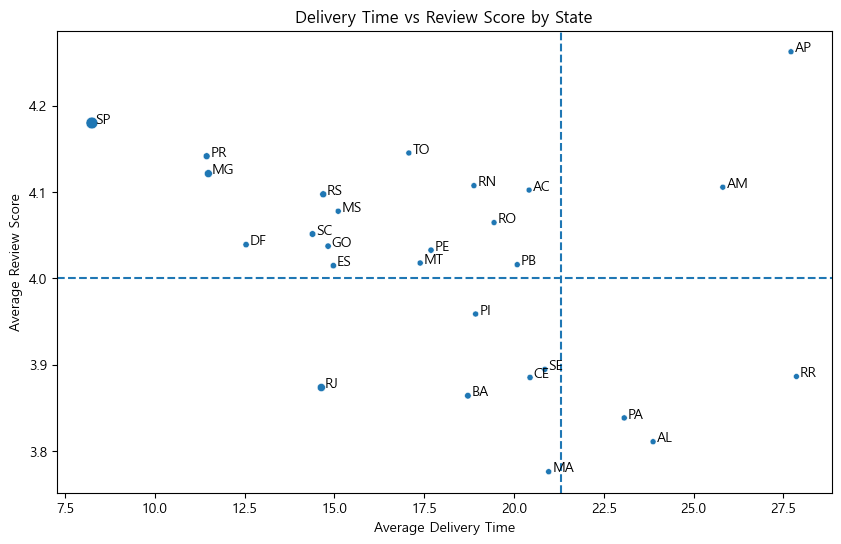

In [18]:
# 배송시간 X 리뷰의 주 확인 그래프에서 배송 느리나 리뷰 높은 곳을 확인하기 -> 확인 결과 AP, AM이 존재함
import seaborn as sns
import matplotlib.pyplot as plt

# 1-1 주(state)별 배송시간 vs 리뷰
state_summary = df.groupby('customer_state').agg({
    'delivery_time':'mean',
    'review_score':'mean',
    'order_id':'count'
}).reset_index()

# scatter plot
plt.figure(figsize=(10,6))

sns.scatterplot(data=state_summary,
                x='delivery_time',
                y='review_score',
                size='order_id',
                legend=False
)

# 주 이름 표시
for i,row in state_summary.iterrows():
    plt.text(row['delivery_time']+0.1,
             row['review_score'],
             row['customer_state'])
    
# review_score = 4 기준선
plt.axhline(y=4.0, linestyle='--')

# 전체 배송시간 평균 및 표준편차
mean_delivery = df['delivery_time'].mean()
std_delivery = df['delivery_time'].std()

# 평균선
# plt.axvline(mean_delivery, linestyle='-', label='Mean')

# +1σ선
plt.axvline(mean_delivery + std_delivery,
            linestyle='--',
            label='+1σ')

plt.title('Delivery Time vs Review Score by State')
plt.xlabel('Average Delivery Time')
plt.ylabel('Average Review Score')

plt.show()

In [19]:
# 1-2 AM / AP 특징 확인
df['is_amap'] = df['customer_state'].isin(['AM','AP'])

df_amap = df[df['is_amap']]

df_amap[['distance','price','freight_value','delivery_time']].describe()

# 데이터규모 : AM+AP주문건 : 243건 (전체데이터는 109000건으로 전체에 대한 비중이 0.22%) - 굉장히 작은 특이 집단임
# 거리 : 평균 2671km의 거리 (전체 평균은 595로 이 곳은 전체의 배송거리 보다 4.4배가 김)
# 배송시간 : 평균 26.47 일 (전체 평균 12일로 전체에 비해 배송시간이 2배이상 걸림)
# 가격 : 평균 145, 중간값 89로 - 고가상품이 평균을 끌어올림 
# 배송비 : 평균 33.6 (전체 평균 20보다 높은 수준)

,distance,price,freight_value,delivery_time
count,241.000000,241.000000,241.000000,241.000000
mean,2626.937552,144.933029,33.514564,26.443983
std,254.139569,214.658607,19.288596,18.955814
min,809.161298,8.500000,0.000000,4.000000
25%,2562.685100,47.490000,24.170000,19.000000
50%,2672.279190,89.900000,27.310000,25.000000
75%,2699.800737,149.900000,34.760000,31.000000
max,3343.265169,1688.000000,165.750000,187.000000



3단계) 가설별 통계 분석

배송이 느린데, 리뷰가 왜 높은가?


가설1. 카테고리 때문일 것이다

카테고리 분포 비교

pd.crosstab(df['customer_state'],df['product_category_name_english'],normalize='index')

카이제곱 검정

from scipy.stats import chi2_contingency

chi2_contingency(pd.crosstab(df['customer_state'],df['product_category_name_english']))

*** 해석 : p < 0.05 → 카테고리 분포 차이 존재


가설2. 거리 때문일 것이다

거리 평균 비교

df.groupby('customer_state')['distance'].mean()

T-test

from scipy.stats import ttest_ind

ttest_ind(df[df.customer_state=='AM']['distance'],df[df.customer_state!='AM']['distance'])


가설3. 가격 영향

df.groupby('customer_state')['price'].mean()

검정

ttest_ind(df[df.customer_state=='AM']['price'],df[df.customer_state!='AM']['price'])


가설4 배송비 영향

df.groupby('customer_state')['freight_value'].mean()

검정

ttest_ind(df[df.customer_state=='AM']['freight_value'],df[df.customer_state!='AM']['freight_value'])


In [20]:
# 가설 1. 카테고리 영향
# 카테고리 확인
# AM/AP 지역 데이터
df_amap = df[df['is_amap']]

# AM/AP에서 많이 구매된 카테고리 Top10
df_amap['product_category_name_english'].value_counts().head(10)

product_category_name_english
health_beauty            30
computers_accessories    24
sports_leisure           20
telephony                19
watches_gifts            17
bed_bath_table           14
toys                     10
auto                      9
electronics               8
stationery                8
Name: count, dtype: int64

In [21]:
# 각 주 별 카테고리 분포 확인하기 (전체 패턴)
pd.crosstab(df['customer_state'],
            df['product_category_name_english'],
            normalize='index')

product_category_name_english,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,...,security_and_services,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts
customer_state,,,,,,,,,,,,,,,,,,,,,
AC,0.000000,0.000000,0.000000,0.000000,0.000000,0.045455,0.034091,0.045455,0.022727,0.000000,...,0.000000,0.000000,0.011364,0.000000,0.102273,0.022727,0.000000,0.045455,0.034091,0.045455
AL,0.002364,0.002364,0.000000,0.000000,0.009456,0.049645,0.016548,0.042553,0.004728,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.075650,0.018913,0.000000,0.063830,0.028369,0.080378
AM,0.000000,0.006211,0.006211,0.000000,0.006211,0.037267,0.031056,0.049689,0.006211,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.080745,0.037267,0.006211,0.093168,0.043478,0.055901
AP,0.012500,0.000000,0.012500,0.000000,0.000000,0.037500,0.000000,0.075000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.087500,0.025000,0.000000,0.050000,0.037500,0.100000
BA,0.001393,0.001672,0.002786,0.000000,0.003901,0.042909,0.025913,0.067986,0.003622,0.000279,...,0.000000,0.001672,0.005015,0.000836,0.079409,0.020619,0.001672,0.066592,0.030928,0.062692
CE,0.004304,0.001435,0.000000,0.000000,0.003587,0.041607,0.022238,0.058106,0.005022,0.000000,...,0.000000,0.000000,0.005022,0.000000,0.064562,0.024390,0.000717,0.065997,0.045194,0.093974
DF,0.000000,0.001395,0.002791,0.000465,0.006977,0.049302,0.028837,0.091163,0.007442,0.000000,...,0.000465,0.000930,0.010698,0.000465,0.097209,0.019535,0.000000,0.036744,0.041395,0.059535
ES,0.000921,0.002302,0.000460,0.000000,0.006446,0.038674,0.028085,0.102210,0.005064,0.000000,...,0.000000,0.002762,0.001381,0.000000,0.079190,0.023941,0.001381,0.050645,0.043738,0.067219
GO,0.002277,0.003188,0.001366,0.000000,0.003188,0.034608,0.024590,0.107923,0.006375,0.000000,...,0.000000,0.002277,0.004554,0.000000,0.073770,0.021858,0.000455,0.054645,0.035519,0.064663


In [22]:
# 전체 주 비교 
# 카이제곱 독립성 검정 
# H0 : customer_state와 product_category는 서로 독립이다 -> 기각 : 주에 따라 구매 상품 카테고리 분포에는 통계적으로 유의한 차이가 존재한다 

from scipy.stats import chi2_contingency

chi2_contingency(
    pd.crosstab(df['customer_state'],
                df['product_category_name_english'])
)

Chi2ContingencyResult(statistic=np.float64(5177.042265098117), pvalue=np.float64(0.0), dof=1820, expected_freq=array([[1.67988732e-01, 2.31596115e-01, 1.59018459e-01, ...,
        3.57179924e+00, 3.23908370e+00, 4.73059530e+00],
       [8.07491289e-01, 1.11324042e+00, 7.64372822e-01, ...,
        1.71689895e+01, 1.55696864e+01, 2.27391115e+01],
       [3.07343020e-01, 4.23715620e-01, 2.90931500e-01, ...,
        6.53476907e+00, 5.92605086e+00, 8.65483913e+00],
       ...,
       [7.06316258e-01, 9.73756394e-01, 6.68600341e-01, ...,
        1.50177923e+01, 1.36188746e+01, 1.98900030e+01],
       [8.72052413e+01, 1.20224702e+02, 8.25486508e+01, ...,
        1.85416969e+03, 1.68145252e+03, 2.45571653e+03],
       [5.78415746e-01, 7.97427534e-01, 5.47529468e-01, ...,
        1.22983542e+01, 1.11527541e+01, 1.62882997e+01]], shape=(27, 71)))

In [23]:
# AM/AP vs 다른 주 비교
from scipy.stats import chi2_contingency
import pandas as pd

# H0 : AM/AP 여부와 카테고리는 독립이다 -> p값으로 기각됨 : AM/AP 지역 소비패턴이 다른 지역과 다를 가능성이 큼

# AM/AP 여부 변수 생성 (True면 AM/AP False면 다른 주) + 상품 카테고리 교차표 생성
table = pd.crosstab(df['is_amap'], df['product_category_name_english'])

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(table); print("Chi2:", chi2, "| p-value:", p, "| dof:", dof)

Chi2: 167.69842146051704 | p-value: 5.418044175923202e-10 | dof: 70


In [24]:
# AM/AP에서 많이 팔리는 카테고리 Top10

top_categories = (
    pd.crosstab(
        df.loc[df['is_amap'], 'customer_state'], 
        df.loc[df['is_amap'], 'product_category_name_english'],
        normalize='index'
    )
    .T
    .sort_values(by='AM', ascending=False)
    .head(10)
)

top_categories

customer_state,AM,AP
product_category_name_english,,
health_beauty,0.124224,0.1250
computers_accessories,0.099379,0.1000
telephony,0.093168,0.0500
sports_leisure,0.080745,0.0875
watches_gifts,0.055901,0.1000
bed_bath_table,0.049689,0.0750
toys,0.043478,0.0375
auto,0.037267,0.0375
stationery,0.037267,0.0250


In [25]:
# 가설 2. 거리 영향
df.groupby('customer_state')['distance'].mean()

customer_state
AC    2639.520957
AL    1834.843648
AM    2645.230268
AP    2590.123460
BA    1343.658698
CE    2188.042666
DF     829.847378
ES     804.307266
GO     774.936526
MA    2105.059260
MG     534.946745
MS     844.404809
MT    1351.273275
PA    2289.690472
PB    2101.319897
PE    1972.681542
PI    1958.853237
PR     486.725996
RJ     489.490946
RN    2098.982003
RO    2220.781054
RR    3244.525459
RS     867.728835
SC     572.366439
SE    1652.294988
SP     248.181661
TO    1483.161525
Name: distance, dtype: float64

In [26]:
# T-test
# H0 : AM 지역은 다른 지역보다 배송 거리가 같다. -> 기각 : 배송거리가 다르다.
from scipy.stats import ttest_ind

ttest_ind(
    df[df.customer_state.isin(['AM','AP'])]['distance'],
    df[~df.customer_state.isin(['AM','AP'])]['distance'],
    equal_var=False
)

TtestResult(statistic=np.float64(123.61400297509887), pvalue=np.float64(3.48868360759593e-223), df=np.float64(245.63637239912273))

In [27]:
# 가설 3️. 가격 영향
df.groupby('customer_state')['price'].mean()

customer_state
AC    178.012159
AL    181.815414
AM    134.161180
AP    166.611375
BA    134.590618
CE    153.473623
DF    125.991005
ES    117.289540
GO    124.157523
MA    145.333613
MG    120.130613
MS    142.912321
MT    147.844951
PA    159.195906
PB    188.202809
PE    144.087564
PI    162.817760
PR    118.382116
RJ    124.210169
RN    157.952246
RO    169.944867
RR    154.806591
RS    119.058500
SC    122.946927
SE    149.758757
SP    109.254302
TO    157.052574
Name: price, dtype: float64

In [28]:
# t검정
# H0 : AM 지역과 타지역 상품 가격은 같다 -> 기각 실패 : AM 지역과 다른 지역간 상품 가격 차이는 통계적으로 유의하지 않았다.
ttest_ind(
    df[df.customer_state.isin(['AM','AP'])]['price'],
    df[~df.customer_state.isin(['AM','AP'])]['price'],
    equal_var=False
)

TtestResult(statistic=np.float64(1.8172299052457495), pvalue=np.float64(0.07042506344981471), df=np.float64(240.76127293194568))

In [29]:
# 가설 4. 배송비 영향 
df.groupby('customer_state')['freight_value'].mean()

customer_state
AC    40.426136
AL    35.773688
AM    33.133478
AP    34.281500
BA    26.447680
CE    32.805265
DF    21.144544
ES    21.980345
GO    22.782300
MA    38.538066
MG    20.643579
MS    23.343877
MT    28.170988
PA    35.407894
PB    43.147898
PE    32.771180
PI    39.263045
PR    20.551467
RJ    20.937950
RN    35.679648
RO    41.384411
RR    43.777500
RS    21.584841
SC    21.559813
SE    36.122811
SP    15.137268
TO    37.738086
Name: freight_value, dtype: float64

In [30]:
# t 검정
# H0 : AM 지역과 다른 지역의 평균 배송비(freight_value)는 같다. -> 기각 : AM 지역과 다른 지역의 평균 배송비가 유의미한 차이를 가지고 있다.
ttest_ind(
    df[df.customer_state.isin(['AM','AP'])]['freight_value'],
    df[~df.customer_state.isin(['AM','AP'])]['freight_value'],
    equal_var=False
)

TtestResult(statistic=np.float64(10.926994925367323), pvalue=np.float64(7.798047555005423e-23), df=np.float64(240.71126865652556))



4단계) 상관분석
목적 : 리뷰에 영향 변수 확인
* Spearman correlation 사용 (리뷰점수는 ordinal)
df[['review_score','delivery_time','distance','price','freight_ratio']].corr(method='spearman')



In [31]:
# 상관 분석 (리뷰점수는 ordinal데이터 -> spearman 사용)
df[['review_score',
    'delivery_time',
    'distance',
    'price',
    'freight_ratio']].corr(method='spearman')

,review_score,delivery_time,distance,price,freight_ratio
review_score,1.000000,-0.221815,-0.065402,0.010122,-0.037182
delivery_time,-0.221815,1.000000,0.538131,0.115388,0.113733
distance,-0.065402,0.538131,1.000000,0.119704,0.206077
price,0.010122,0.115388,0.119704,1.000000,-0.808699
freight_ratio,-0.037182,0.113733,0.206077,-0.808699,1.000000


In [32]:
from scipy.stats import spearmanr

cols = ['review_score','delivery_time','distance','price','freight_ratio']

corr, pval = spearmanr(df[cols])

corr_df = pd.DataFrame(corr, index=cols, columns=cols)
pval_df = pd.DataFrame(pval, index=cols, columns=cols)

display(corr_df, pval_df)

,review_score,delivery_time,distance,price,freight_ratio
review_score,1.000000,-0.221815,-0.065402,0.010122,-0.037182
delivery_time,-0.221815,1.000000,0.538131,0.115388,0.113733
distance,-0.065402,0.538131,1.000000,0.119704,0.206077
price,0.010122,0.115388,0.119704,1.000000,-0.808699
freight_ratio,-0.037182,0.113733,0.206077,-0.808699,1.000000


,review_score,delivery_time,distance,price,freight_ratio
review_score,0.000000e+00,0.000000e+00,1.270688e-102,0.000883,2.447306e-34
delivery_time,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.542161e-307
distance,1.270688e-102,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
price,8.825743e-04,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
freight_ratio,2.447306e-34,1.542161e-307,0.000000e+00,0.000000,0.000000e+00


5단계) 머신러닝 모델
목적 : 리뷰점수를 설명하는 핵심 변수 확인
타겟 : review_score
피처 :
delivery_time distance price freight_value freight_ratio product_category

5-1 모델 데이터 준비
X = df[['delivery_time','distance','price','freight_ratio']]
y = df['review_score']

5-2 train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

5-3 모델 1 RandomForest
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)

5-4 feature importance
pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)



6단계) Feature Importance 해석

: 거리 영향이 가장 큼


7단계) AM AP 추가 검증

모델 동일 수행 : 특정 지역에서 변수 중요도가 다른지 확인

AM AP 데이터만 모델

df_state = df[df['customer_state'].isin(['AM','AP'])]

: 배송시간과의 영향이 가장 크긴 했지만 나머지도 비슷한 영향을 주는 것으로 확인 됨


* 최종 인사이트 구조

예시

1 배송시간이 리뷰에 가장 큰 영향

2 배송거리는 배송시간을 증가시키는 구조

3 배송비 절대값 영향 작음

4 배송비 비율은 일부 영향


최종 스토리
리뷰는 단순히 배송이 늦어서 나빠지는 것이 아니라

배송시간
배송거리
가격 대비 배송비

이 조합에 의해 결정된다.

즉 고객 경험은 판매자의 물류 품질을 설명하는 지표이다.

---

# 1-3) 배송비 비중

In [33]:
# 날짜형 변환
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 배송일수(구매→실배송)
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# 배송 지연 여부(실배송 > 예상배송)
df['is_delayed'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

In [34]:
# 1. 주문 단위로 상품가격 / 배송비 집계
order_price_freight = df.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()

# 2. 리뷰와 merge
# 리뷰 1개(order_id 1개)당 한 행이 되도록 맞춤
df_review_freight_order = order_price_freight.merge(
    df[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# 3. 상품 총가격이 0인 경우 제거
df_review_freight_order = df_review_freight_order[
    df_review_freight_order['total_price'] > 0
].copy()

# 4. 배송비 비율 계산
df_review_freight_order['freight_ratio'] = (
    df_review_freight_order['total_freight'] /
    df_review_freight_order['total_price']
)

# 5. 구간 나누기
bins = [0, 0.1, 0.3, 0.5, 1, 2, 5, np.inf]
labels = ['0~0.1', '0.1~0.3', '0.3~0.5', '0.5~1', '1~2', '2~5', '5~']

df_review_freight_order['freight_bin'] = pd.cut(
    df_review_freight_order['freight_ratio'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 6. 확인
print("주문 단위 행 수:", len(df_review_freight_order))
print("리뷰 점수 수:", df_review_freight_order['review_score'].count())
print("배송비 구간 수:", df_review_freight_order['freight_bin'].value_counts().sum())
print("배송비 구간 NaN:", df_review_freight_order['freight_bin'].isna().sum())

# 7. 구간별 평균 리뷰 점수
ratio_review = df_review_freight_order.groupby('freight_bin')['review_score'].mean()
display(ratio_review)

# 8. 구간별 개수
display(df_review_freight_order['freight_bin'].value_counts().sort_index())

주문 단위 행 수: 107934
리뷰 점수 수: 107934
배송비 구간 수: 107934
배송비 구간 NaN: 0


freight_bin
0~0.1      4.174871
0.1~0.3    4.099248
0.3~0.5    4.024881
0.5~1      4.047987
1~2        3.945739
2~5        3.947743
5~         2.324324
Name: review_score, dtype: float64

freight_bin
0~0.1      16109
0.1~0.3    52414
0.3~0.5    21583
0.5~1      14108
1~2         3262
2~5          421
5~            37
Name: count, dtype: int64

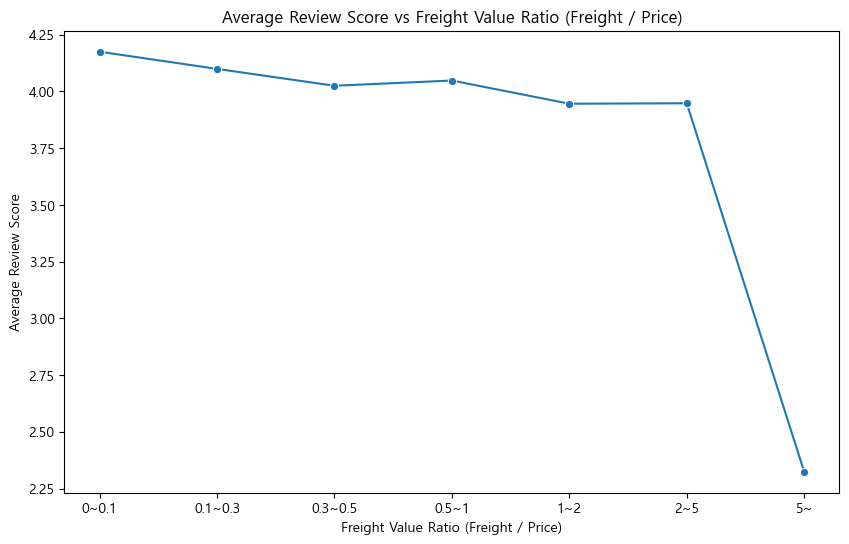

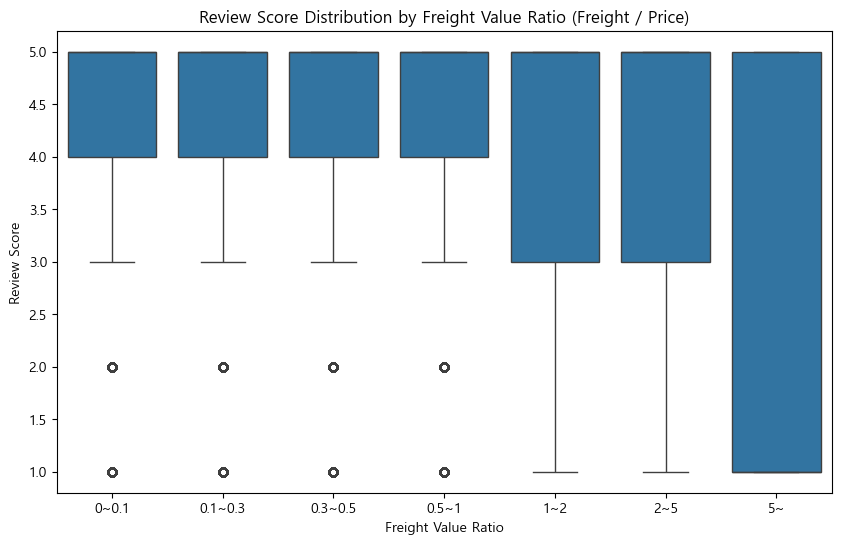

In [35]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=ratio_review.index.astype(str),
    y=ratio_review.values,
    marker='o'
)

plt.title("Average Review Score vs Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio (Freight / Price)")
plt.ylabel("Average Review Score")

plt.show()

###

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_review_freight_order,
    x='freight_bin',
    y='review_score'
)

plt.title("Review Score Distribution by Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio")
plt.ylabel("Review Score")

plt.show()

In [36]:
corr, p = spearmanr(
    df_review_freight_order['freight_ratio'],
    df_review_freight_order['review_score']
)

print(corr, p)

-0.04018782222739244 7.867037726153917e-40


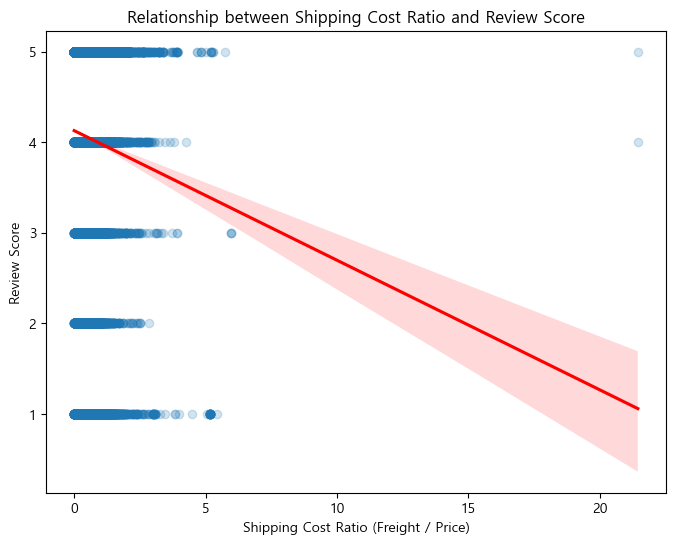

In [37]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_review_freight_order,
    x='freight_ratio',
    y='review_score',
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.title("Relationship between Shipping Cost Ratio and Review Score")
plt.xlabel("Shipping Cost Ratio (Freight / Price)")
plt.ylabel("Review Score")

plt.show()